In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt   

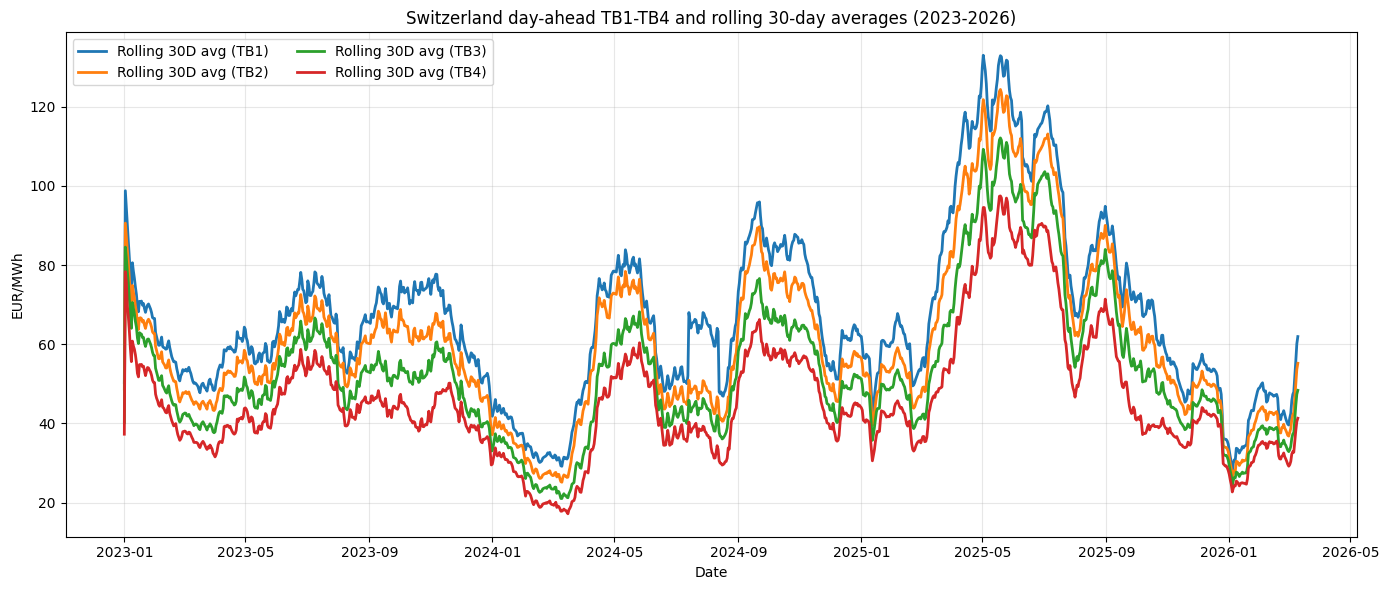

In [6]:
from pathlib import Path
# --- load all spot-market CSV files (supports both wide and long formats) ---
data_dir = Path("C:/Users/ThijsAntoniedeBoer/Downloads/woche 1")
csv_files = sorted(data_dir.glob("auction_spot_prices_switzerland_*.csv"))
if not csv_files:
    raise FileNotFoundError("No matching auction_spot_prices_switzerland_*.csv files found.")

# --- plot switches ---
INCLUDE_DAILY_TB = False   # True: plot daily TB lines + rolling averages; False: rolling averages only

def tb_spreads(values):
    vals = np.sort(values[~np.isnan(values)])
    out = []
    for k in range(1, 5):
        if len(vals) >= 2 * k:
            out.append(vals[-k] - vals[k - 1])
        else:
            out.append(np.nan)
    return out
tb_frames = []
for f in csv_files:
    d = pd.read_csv(f, comment="#")
    # Format A (2023+): one row per day with Hour columns
    if "Delivery day" in d.columns:
        d["Delivery day"] = pd.to_datetime(d["Delivery day"], dayfirst=True, errors="coerce")
        hour_cols = [c for c in d.columns if c.startswith("Hour")]
        d[hour_cols] = d[hour_cols].apply(pd.to_numeric, errors="coerce")
        tb_vals = d[hour_cols].apply(lambda r: tb_spreads(r.to_numpy(dtype=float)), axis=1, result_type="expand")
        tb_vals.columns = ["TB1", "TB2", "TB3", "TB4"]
        t = pd.concat([d[["Delivery day"]], tb_vals], axis=1)
        t = t.dropna(subset=["Delivery day"])
        tb_frames.append(t)
    # Format B (2022): one row per hour with MTU + Price
    elif "MTU (CET/CEST)" in d.columns and "Price" in d.columns:
        d["Price"] = pd.to_numeric(d["Price"], errors="coerce")
        # Extract start date from strings like '01/01/2022 00:00 - 01/01/2022 01:00'
        d["Delivery day"] = pd.to_datetime(
            d["MTU (CET/CEST)"].astype(str).str.extract(r"(\d{2}/\d{2}/\d{4})")[0],
            dayfirst=True,
            errors="coerce",
        )
        d2 = d.dropna(subset=["Delivery day", "Price"]).copy()
        g = d2.groupby("Delivery day")["Price"].apply(
            lambda s: pd.Series(tb_spreads(s.to_numpy(dtype=float)), index=["TB1", "TB2", "TB3", "TB4"])
        )
        t = g.unstack().reset_index()
        tb_frames.append(t)
if not tb_frames:
    raise ValueError("No supported CSV format found in the selected files.")
df = pd.concat(tb_frames, ignore_index=True)
df = df.dropna(subset=["Delivery day"]).sort_values("Delivery day")

# If overlapping dates exist across files, keep one row per day
df = df.groupby("Delivery day", as_index=False)[["TB1", "TB2", "TB3", "TB4"]].mean()
# --- rolling 30-day averages ---
tb_cols = ["TB1", "TB2", "TB3", "TB4"]
for col in tb_cols:
    df[f"{col}_rolling_30d"] = df[col].rolling(window=30, min_periods=1).mean()
# --- plot (daily TB1..TB4 + rolling 30d averages) ---
year_min = int(df["Delivery day"].dt.year.min())
year_max = int(df["Delivery day"].dt.year.max())
plt.figure(figsize=(14, 6))
if INCLUDE_DAILY_TB:
    for col in tb_cols:
        plt.plot(df["Delivery day"], df[col], label=f"Daily {col}", alpha=0.35)
for col in tb_cols:
    plt.plot(df["Delivery day"], df[f"{col}_rolling_30d"], label=f"Rolling 30D avg ({col})", linewidth=2)
plt.title(f"Switzerland day-ahead TB1-TB4 and rolling 30-day averages ({year_min}-{year_max})")
plt.xlabel("Date")
plt.ylabel("EUR/MWh")
plt.legend(ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [15]:
# --- battery input parameters ---
battery_energy_capacity_mwh = 0.215
battery_power_mw = 0.108
round_trip_efficiency = 0.90
max_daily_cycles = 2

# Proxy threshold used to count whether a TB spread is worth cycling.
# Keep this at 0.0 if you only want to count raw spread opportunities.
min_spread_for_cycle_eur_per_mwh = 0.0

battery_duration_hours = battery_energy_capacity_mwh / battery_power_mw


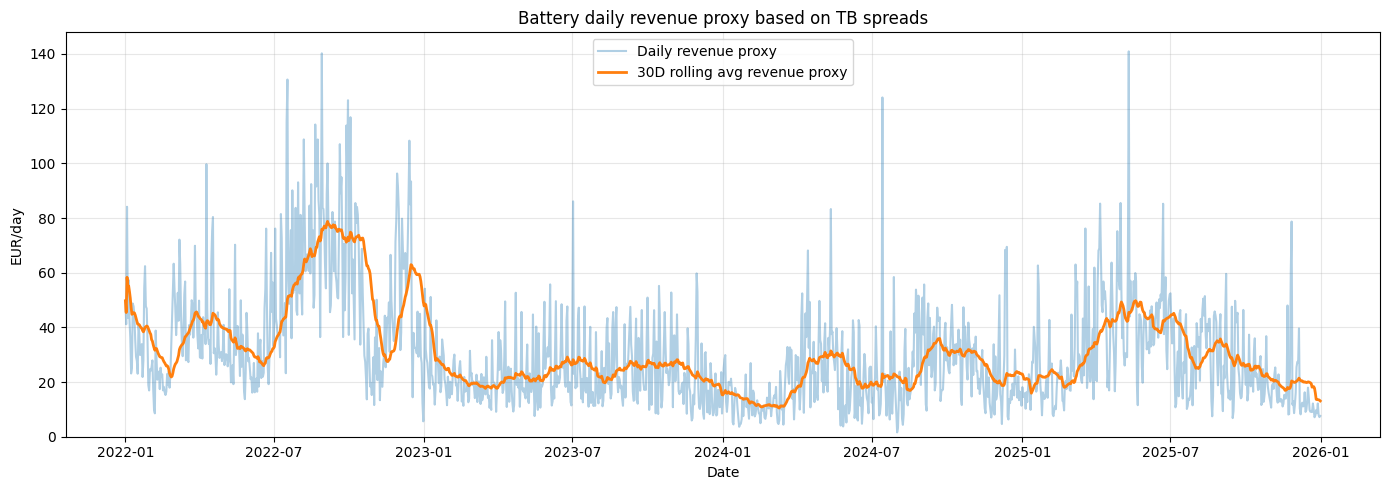

Technical max full cycles/day from duration: 6
Cycles used in revenue proxy: 2


In [ ]:
# --- daily battery revenue proxy from TB spreads ---
cycle_cols = ["TB1", "TB2", "TB3", "TB4"]

if battery_duration_hours <= 0:
    raise ValueError("battery_duration_hours must be positive.")

# A full cycle needs one full charge block and one full discharge block.
technical_max_cycles_per_day = int(np.floor(24 / (2 * battery_duration_hours)))
technical_max_cycles_per_day = max(0, technical_max_cycles_per_day)

cycles_used_per_day = min(max_daily_cycles, technical_max_cycles_per_day, len(cycle_cols))
selected_tb_cols = cycle_cols[:cycles_used_per_day]
energy_per_cycle_mwh = battery_energy_capacity_mwh

# This is a revenue proxy, not a full dispatch optimization.
# It assumes the battery captures the best daily TB spreads up to the cycle limit.
if selected_tb_cols:
    df["daily_revenue_proxy_eur"] = (
        df[selected_tb_cols]
        .clip(lower=min_spread_for_cycle_eur_per_mwh)
        .sum(axis=1)
        * energy_per_cycle_mwh
        * round_trip_efficiency
    )
else:
    df["daily_revenue_proxy_eur"] = 0.0
df["daily_revenue_proxy_rolling_30d_eur"] = df["daily_revenue_proxy_eur"].rolling(window=30, min_periods=1).mean()

plt.figure(figsize=(14, 5))
plt.plot(df["Delivery day"], df["daily_revenue_proxy_eur"], label="Daily revenue proxy", alpha=0.35)
plt.plot(
    df["Delivery day"],
    df["daily_revenue_proxy_rolling_30d_eur"],
    label="30D rolling avg revenue proxy",
    linewidth=2,
)
plt.title("Battery daily revenue proxy based on TB spreads")
plt.xlabel("Date")
plt.ylabel("EUR/day")
plt.ylim(bottom=0)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
